# PLSDA: PLS Discriminant Analysis

PLS discriminant analysis or PLSDA is a supervised classification method. PLSDA is a modification of partial least square regression that makes it suited for classification, where the components separate the classes. Unlike its sparse counterpart `splsda`, PLSDA does not do variable selection, so every variable contributes to each component.


In this documentation, we will depomstrate implementation of PLSDA using `BigRiverEssence.plsda` on a `SRBCT` dataset. 


## The method

Let us consider a vector of classes where the $i$th component indicates the class of the $i$th observation. Let $X$ be a matrix of predictors with variables being the columns and observations being the rows. In PLSDA, the class labels are first
dummy-encoded such that we get an indicator matrix $Y$ from the vector of classes, where $Y_{ik} = 1$ if sample $i$ belongs
to class $k$. PLSDA then performs a PLS regression of the predictors $X$ onto this indicator matrix $Y$. 

In PLSDA, we find each component by obtaining loading vectors $u$ (over variables) and $v$ (over
classes) such that we maximize the covariance between the variable side score $Xu$ and the
class side score $Yv$. Hence the optimization probem can be written as: $$\max_{u,v} \; \operatorname{cov}(Xu, Yv) \quad \text{subject to } \|u\|_2 = \|v\|_2 = 1.$$ Unlike `splsda`, no penalty is applied to $u$, so all variables contribute to each loading. We then solve the component by alternating power iteration where we update $u$ from the class scores, then we update $v$ from the variable scores — until the loadings converge. We then deflate both the variable block $X$ and the class block $Y$ by regressing on the variable score (the regression mode). We then extract the next component from the residual.

The result gives, per component, a dense loading over all variables and sample scores that separate the classes.



## The data

We use the `SRBCT` dataset from the `mixOmics` package. The SRBCT (Small Round Blue Cell Tumors) dataset contains expression levels of $2308$
genes on $63$ samples across four tumor classes — Ewing sarcoma (EWS), Burkitt lymphoma
(BL), neuroblastoma (NB), and rhabdomyosarcoma (RMS) — from Khan et al. (2001) [1],
obtained via the mixOmics R package [2]. The goal is to build components that can best discremenate the tumour classes. 


In [9]:
using BigRiverEssence, DelimitedFiles, Plots, Statistics


In [10]:
datadir = joinpath(pkgdir(BigRiverEssence), "reference_Data", "srbctdata")
X = readdlm(joinpath(datadir, "gene.csv"), ',', Float64)          # 63 × 2308 gene expression
y = vec(readdlm(joinpath(datadir, "class.csv"), String))          # 63 class labels
size(X), unique(y)

((63, 2308), ["EWS", "BL", "NB", "RMS"])

## Fitting the model

Now we fit `plsda` to the predictor matrix $X$. We also pass the number of components we want to have as `ncomp`. Unlike `splsda`, there is no `keepX` since PLSDA does not select variables. We fit three components.


In [11]:
ncomp = 3
m = plsda(X, y, ncomp)

# unlike splsda, the loadings are dense — every gene contributes to each component
[count(!iszero, m.loadings_X[:, c]) for c in 1:m.ncomp]

3-element Vector{Int64}:
 2308
 2308
 2308

The fitted `Plsda` holds the sample scores (`variates_X`), the dense gene
loadings (`loadings_X`), the class labels, and the dummy encoding.

## Sample plot

Now we project the samples onto the first two components and color by tumor class. This will show us how the discriminant components separate the types.


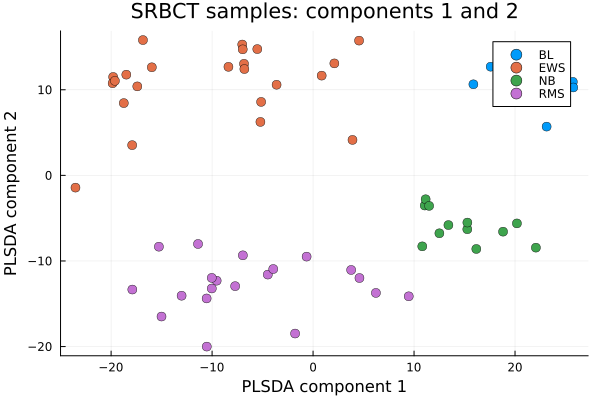

In [12]:
V = m.variates_X
scatter(V[:, 1], V[:, 2]; group = y,
    xlabel = "PLSDA component 1", ylabel = "PLSDA component 2",
    title = "SRBCT samples: components 1 and 2", legend = :topright,
    markersize = 5, markerstrokewidth = 0.5)

We note from the above plot that components $1$ and $2$ are able to separate the four tumor types. Component 1 separates BL from EWS and NB from RMS. Hwere as component 1 separates BL and EWS from NB and RMS. Hence we see 4 clusters at four corners. 



## Top genes by loading

Since PLSDA does not select variables, every gene has a nonzero loading. To see which genes define a component, we look at the ones with the largest-magnitude loadings. We plot the discriminant weights of the $40$ genes with the largest absolute loading on component $1$ as a bar plot.


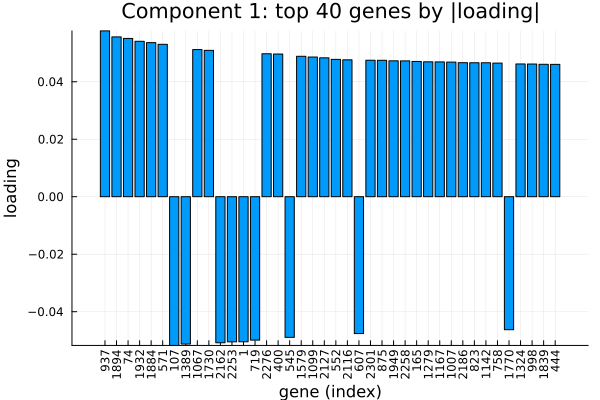

In [13]:
L1 = m.loadings_X[:, 1]
sel = sortperm(abs.(L1); rev = true)[1:40]     # the 40 largest-magnitude genes on component 1

bar(L1[sel]; xticks = (1:length(sel), string.(sel)), xrotation = 90,
    legend = false, xlabel = "gene (index)", ylabel = "loading",
    title = "Component 1: top $(length(sel)) genes by |loading|")

## Variable importance (VIP)

VIP (Variable Importance in Projection) summarizes each gene's contribution across all
components into a single score. We compute it as in `mixOmics`: variables with VIP above
$1$ are of above-average importance.


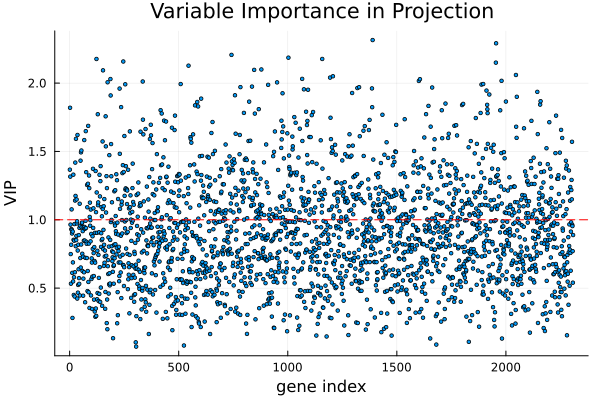

In [14]:
function vip(m)
    W = m.loadings_X
    H = m.ncomp
    Y = m.Y_dummy
    p = size(W, 1)
    VIP = zeros(p, H)
    cor2 = reshape(cor(Y, m.variates_X).^2, size(Y, 2), H)
    VIP[:, 1] .= W[:, 1].^2
    for h in 2:H
        Rd = vec(sum(cor2[:, 1:h], dims = 1))
        VIP[:, h] = (W[:, 1:h].^2 * Rd) ./ sum(Rd)
    end
    return sqrt.(p .* VIP)
end

vip_final = vip(m)[:, end]           # cross-component VIP

scatter(vip_final; markersize = 2, legend = false,
    xlabel = "gene index", ylabel = "VIP",
    title = "Variable Importance in Projection")
hline!([1.0], color = :red, linestyle = :dash)

Since PLSDA uses all the genes, the VIP is spread across many variables rather than
concentrated on a selected few. The genes above the dashed line at VIP = $1$ are the
most influential across the three components.

## Summary

In this example, we used a dataset with $63$ samples and $2308$ genes. The `plsda` model we fitted built three components that separate the four tumor types using all of the genes. `plsda` can be used in any such dataset where the goal is discriminent analysis and the number of predictor variables exceeds the number of rows. When variable selection is also desired, `splsda` adds sparsity on top of this same model.

## References


[1] Khan, J., Wei, J. S., Ringnér, M., et al. (2001). Classification and diagnostic
    prediction of cancers using gene expression profiling and artificial neural networks.
    *Nature Medicine*, 7(6), 673–679.


[2] Rohart, F., Gautier, B., Singh, A., & Lê Cao, K.-A. (2017). mixOmics: An R package
    for 'omics feature selection and multiple data integration. *PLoS Computational
    Biology*, 13(11), e1005752.
